<a href="https://colab.research.google.com/github/Cavalheiro93/mvp-machine-learning-spotify-tracks/blob/main/projeto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto Machine Learning | Spotify Tracks

## 00. Sumário & Setup

| **Recursos de Áudio**   | **Descrição** |
|--------------------------|---------------|
| ``track_id``                 | Id ou código da faixa |
| ``artists``                  | Nome do artista ou banda da faixa |
| ``album_name``               | Nome do album da faixa |
| ``track_name``               | Nome da faixa musical |
| ``popularidade``             | Popularidade da faixa (0 a 100) |
| ``duration_ms``              | Duração em milisegundos da faixa |
| ``explicit``                 | Binário, se a faixa é explicita ou não (se contém palavrão ou não) |
| ``danceability``             | Adequação da faixa para dança (0,0 a 1,0) |
| ``energy``                   | Medida perceptiva de intensidade e atividade (0,0 a 1,0) |
| ``key``                      | Tom da faixa, varia de -1 a -11 |
| ``loudness``                 | Volume geral da faixa em decibéis (-60 a 0 dB) |
| ``mode``                     | Modalidade da faixa (Maior ‘1’ / Menor ‘0’) |
| ``speechiness``              | Presença de palavras faladas na faixa |
| ``acousticness``             | Medida de confiança (0 a 1) de que a faixa é acústica |
| ``instrumentalness``         | Indica se a faixa contém vocais (0,0 a 1,0) |
| ``liveness``                 | Presença de público na gravação (0,0 a 1,0) |
| ``valence``                  | Positividade musical (0,0 a 1,0) |
| ``tempo``                    | Tempo da faixa em batidas por minuto (BPM), Na terminologia musical indica a velocidade ou ritmo da música. |
| ``time_signature``           | Compasso estimado (3 a 7) |
| ``track_genre``              | O gênero ao qual a faixa pertence |

## 01. Contexto & Definição do Problema

Criar um modelo que recomende músicas de rock de acordo com o humor/atividade do usuário (ex.: academia, leitura, relax).

Objetivo prático: dado um conjunto de atributos musicais, classificar cada faixa em um rótulo de humor/atividade

## 02. Dados & Carregamento (via URL do GitHub)

### Imports

In [1]:
# configuração para não exibir os warnings
import warnings
warnings.filterwarnings("ignore")

import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import silhouette_score
from sklearn.metrics import accuracy_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [2]:

pd.set_option('display.max_columns', None)

# Filtro das colunas que usaremos somente
usecols = ['artist_name', 'track_name', 'track_id', 'popularity', 'genre', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

# O estudo será baseado apenas em gêneros de rock
genre_rock = ['alt-rock', 'black-metal', 'death-metal', 'emo', 'hard-rock', 'hardcore', 'heavy-metal', 'metal', 'metalcore',
              'goth', 'psych-rock', 'punk', 'punk-rock', 'rock', 'rock-n-roll', 'grunge', 'alternative']

df = pd.read_csv("hf://datasets/maharshipandya/spotify-tracks-dataset/dataset.csv", low_memory=False)

#renomear track_genre para genre
df = df.rename(columns={'track_genre': 'genre', 'artists': 'artist_name'})

df = df[usecols]

# Somente generos de rock
filtro_rock = df['genre'].isin(genre_rock)
#Somente musicas com popularidade maior que 30, para eliminar musicas muito desconhecidas
filtro_popularidade = df['popularity'] > 1
# Somente musicas com instrumentalidade maior que 0.5, para eliminar podcasts
#filtro_instrumentalness = df['instrumentalness'] > 0.1
#speechiness maior que 0
filtro_speechiness = df['speechiness'] != 0

# Aplicando os filtros
df = df[filtro_rock]
#df = df[filtro_instrumentalness]
df = df[filtro_popularidade]
df = df[filtro_speechiness]


In [4]:
# Garantir nomes limpos (opcional)
df['artist_name'] = df['artist_name'].astype(str).str.strip()

# 1) Tabela de contagens por artista x gênero
tabela = pd.crosstab(df['artist_name'], df['genre'])

# 2) Reorganiza colunas na ordem de genre_rock e preenche ausências com 0
tabela = tabela.reindex(columns=genre_rock, fill_value=0)

# 3) Gênero mais frequente por artista
# Obs.: em caso de empate, idxmax pega o primeiro na ordem de 'genre_rock'
genre_grouped = tabela.idxmax(axis=1)

# 4) Resultado final
genre_grouped = tabela.assign(genre_grouped=genre_grouped).reset_index()

In [5]:
# Substitui a coluna 'genre' pelo agrupado
df = df.drop(columns=['genre'])  # remove o antigo
df = df.merge(genre_grouped[['artist_name', 'genre_grouped']],
              on='artist_name', how='left')

# Renomeia para manter só 'genre'
df = df.rename(columns={'genre_grouped': 'genre'})

mapa_generos = {
    "punk": "punk",
    "punk-rock": "punk",
    "rock": "alternative rock",
    "alt-rock": "alternative rock",
    "alternative": "alternative rock",
    "grunge": "alternative rock",
    "heavy-metal": "heavy-metal and goth",
    "goth": "heavy-metal and goth",
    "hard-rock": "heavy-metal and goth",
    "metal": "new metal",
    "metalcore": "new metal",
}

# aplicar o mapeamento
df["genre_grouped"] = df["genre"].map(lambda g: mapa_generos.get(g, g))

# remover a coluna antiga de gênero
df.drop(columns=['genre'], inplace=True)

# ordenar por popularidade decrescente
df = df.sort_values(by='popularity', ascending=False)

#remover duplicadas onde o track_id é igual, mantendo a mais popular
df = df.drop_duplicates(subset=['track_id'], keep='first')

In [6]:
# Removeção do grupo "outros"
df = df.copy()

# Somente colunas para o modelo
df_ml = df.drop(columns=["key", "mode", "artist_name", "track_name", "track_id", 'popularity',
                         'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', ])

# Somente colunas para o modelo, SEGUNDA TENTATIVA
df_ml = df.drop(columns=["key", "mode", "artist_name", "track_name", "track_id", 'speechiness', 'liveness'])

# Somente colunas para o modelo, TERCEIRA TENTATIVA
#df_ml = df.drop(columns=["key", "mode", "artist_name", "track_name", "track_id", 'speechiness', 'liveness', 'acousticness', 'instrumentalness'])

## 03. Análise Exploratória (EDA)

#### Dimensão do Dataset

In [7]:
# Após todos os tratamentos iniciais, temos a dimensão final do dataset
df_ml.shape

(11765, 9)

In [8]:
df_ml.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11765 entries, 13741 to 14049
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   popularity        11765 non-null  int64  
 1   danceability      11765 non-null  float64
 2   energy            11765 non-null  float64
 3   loudness          11765 non-null  float64
 4   acousticness      11765 non-null  float64
 5   instrumentalness  11765 non-null  float64
 6   valence           11765 non-null  float64
 7   tempo             11765 non-null  float64
 8   genre_grouped     11765 non-null  object 
dtypes: float64(7), int64(1), object(1)
memory usage: 919.1+ KB


- *não temos valores nulos em nenhuma das colunas*
- *No dataset geral temos 3 tipos de variaveis, sendo object, int e float*

#### Estatísticas Descritivas das variáveis numéricas

In [9]:
df_ml.describe().T

,count,mean,std,min,25%,50%,75%,max
popularity,11765.0,41.514407,18.077210,2.00000,26.000000,38.00000,57.0000,96.000
danceability,11765.0,0.475940,0.158029,0.05130,0.370000,0.47800,0.5770,0.969
energy,11765.0,0.770832,0.207073,0.00002,0.638000,0.84400,0.9420,1.000
loudness,11765.0,-6.599569,3.196052,-29.86700,-8.160000,-5.87000,-4.3690,1.023
acousticness,11765.0,0.132649,0.233448,0.00000,0.000324,0.00817,0.1430,0.996
instrumentalness,11765.0,0.104291,0.240437,0.00000,0.000000,0.00013,0.0235,0.993
valence,11765.0,0.437394,0.241401,0.01770,0.241000,0.41200,0.6130,0.993
tempo,11765.0,126.060998,30.218399,34.82100,101.183000,124.06200,146.9950,215.513


- **Popularity**: ampla variação entre músicas pouco e muito populares (mín. 2, máx. 96), média em torno de 42.  
- **Danceability**: distribuição equilibrada (média ~0.47), variando de músicas pouco dançantes a bastante dançantes.  
- **Energy**: valores geralmente altos (média ~0.76), confirmando que a maioria das faixas tem perfil energético típico do rock.  
- **Loudness**: média em torno de -6.6 dB, mas com grande variação (-29 até +1), indicando diferenças relevantes de intensidade sonora.  
- **Valence**: média ~0.43, mostrando equilíbrio entre faixas mais “alegres” e mais “melancólicas”, com grande dispersão (0.02 a 0.99).  
- **Tempo (BPM)**: média ~126 bpm, mas com músicas desde muito lentas (34 bpm) até muito rápidas (215 bpm).  


#### Mini gráficos para visualização de cada campo

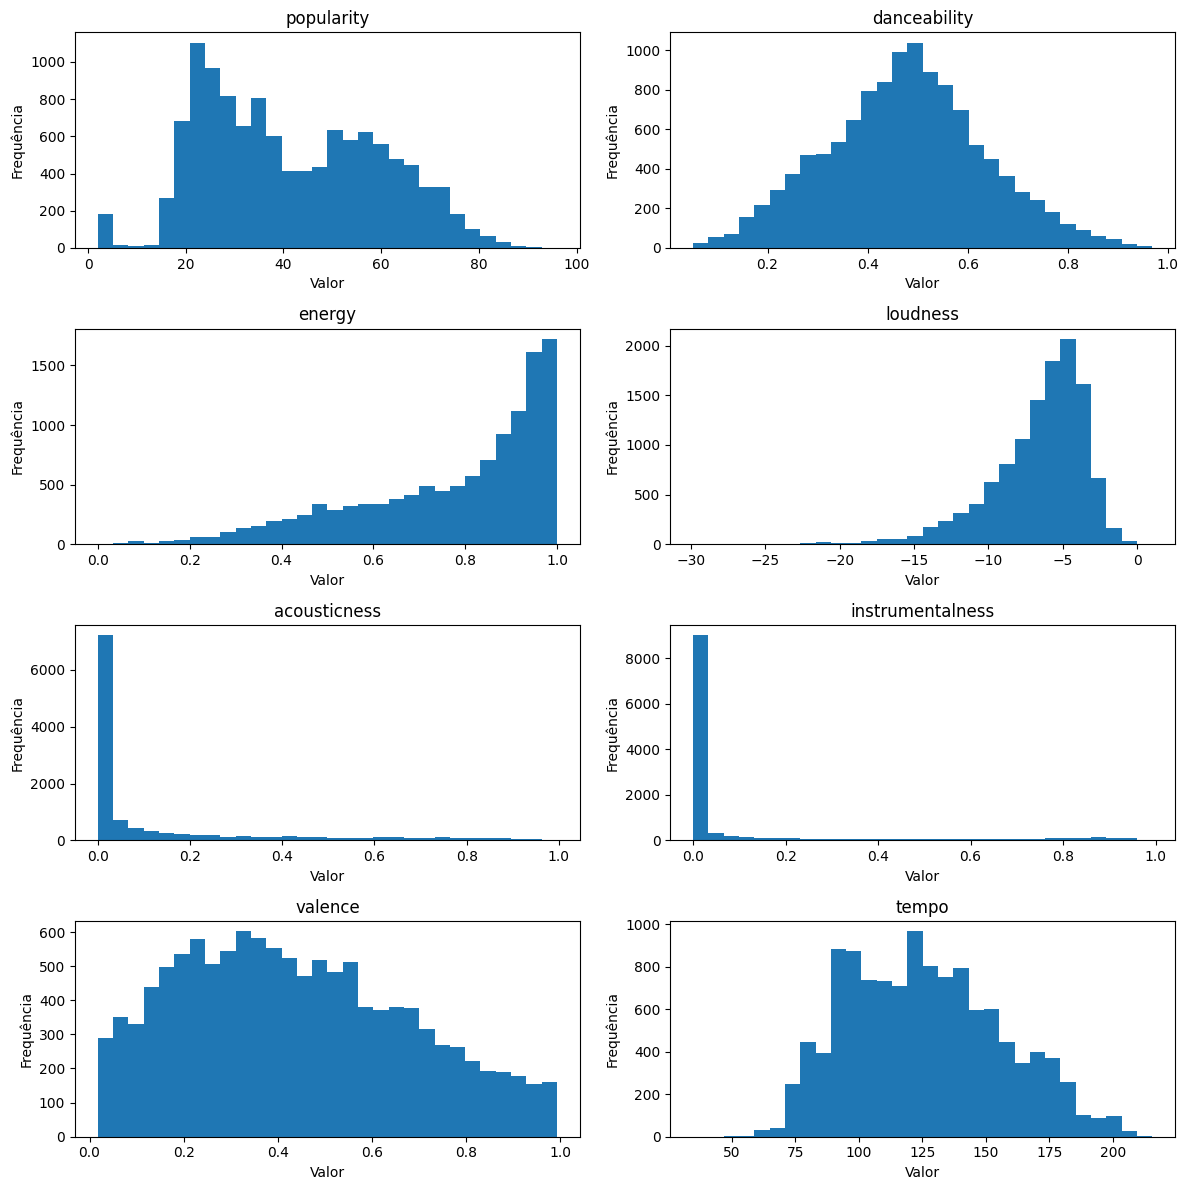

In [10]:
from matplotlib import pyplot as plt

# 1) Lista automática das colunas numéricas (não pega as categóricas nem o target)
numeric_cols = df_ml.select_dtypes(include="number").columns.tolist()

# 2) Grid dinâmico (2 colunas) – funciona com qualquer quantidade de variáveis
n = len(numeric_cols)
rows = (n + 1) // 2  # arredonda pra cima
fig, axes = plt.subplots(nrows=rows, ncols=2, figsize=(12, 3*rows))
axes = axes.ravel()

# 3) Plota os histogramas
for i, col in enumerate(numeric_cols):
    axes[i].hist(df_ml[col].dropna(), bins=30)
    axes[i].set_title(col)
    axes[i].set_xlabel("Valor")
    axes[i].set_ylabel("Frequência")

# 4) Se sobrar “ax” vazio (quando n for ímpar), remove do layout
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


Overview dos gráficos
- *Popularity* tem boa distribuição, entretanto as faixas dificilmente passam dos 80, afirmando que o rock não é tão popular nos dias de hoje.
- Maior concentração dos valores de *danceability* no centro do gráfico, entre os valores 0.4 e 0.6, indicando uma grande variedade de estilos de música dentro do mesmo gênero.
- *energy* e *loudness* com maior parte dos seus valores na extremidade da direita. Pode indicar que faixas de rock sejam mais enérgicas e geralmente com volume bem alto.
- Outros campos como *acousticness* e *instrumentalness*, temos grande concentração dos valores proximos de 0.
- No campo *valence* temos uma grande dispersão entre valores 0 e 1, com maior concentração em 0.2 a 0.5, indicando que temos uma grande mistura de estilos musicais.
- No campo *tempo* temos maior concentração entre 50 e 200 BPM. No gênero rock poucas musicas tem ritmo muito lento ou rápido demais.

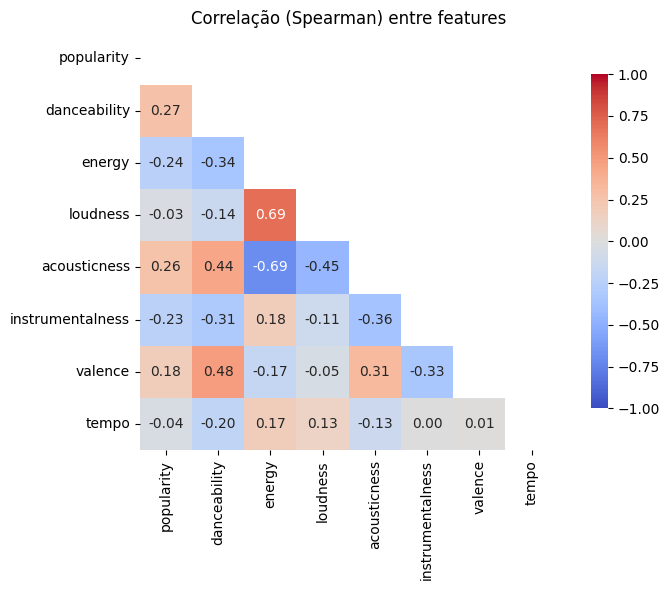

In [11]:
# 1) Seleciona apenas features numéricas (ignora 'genre_grouped')
num_cols = df_ml.select_dtypes(include="number").columns
corr = df_ml[num_cols].corr(method="spearman")  # use "pearson" se preferir

# 2) Heatmap (triângulo inferior, com anotações)
mask = np.triu(np.ones_like(corr, dtype=bool))  # esconde triângulo superior
plt.figure(figsize=(8,6))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", vmin=-1, vmax=1, square=True,
            cbar_kws={"shrink": .8})
plt.title("Correlação (Spearman) entre features")
plt.tight_layout()
plt.show()